## 🚀 스프린트 미션: 딥러닝 기반 뉴스 카테고리 분류

### 0\. 미션 소개 및 목표

이번 미션의 목표는 텍스트 데이터를 처리하고 RNN 기반 딥러닝 모델을 구현하여 **뉴스 기사의 카테고리를 분류**하는 것입니다.

  * **핵심 과제:** **Word2Vec, FastText, GloVe** 세 가지 임베딩 방식의 성능을 비교 분석합니다.
  * **사용 데이터셋:** 'News Group 20' (18,846개 뉴스 문서, 20개 카테고리)
    ```python
    from sklearn.datasets import fetch_20newsgroups
    # 헤더, 푸터, 인용문 제외
    news_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
    ```

-----

### 1\. 데이터 전처리

  * **토큰화 (Tokenization):** 텍스트 데이터를 토큰(단어) 단위로 분리합니다.
  * **데이터 분리 (Data Split):** 전체 데이터를 훈련(Train) 세트와 테스트(Test) 세트로 적절히 나눕니다.

### 2\. 임베딩 적용

  * **임베딩 행렬 준비:** 3가지 임베딩 방식(Word2Vec, FastText, GloVe)을 각각 사용하여, 텍스트 데이터를 벡터화하고 모델의 `Embedding Layer`에 적용할 임베딩 행렬(Embedding Matrix)을 준비합니다.
      * *Tip: 사전 학습된(Pre-trained) 임베딩 벡터를 활용할 수 있습니다.*

### 3\. 데이터셋 및 로더 구현 (PyTorch)

  * **커스텀 데이터셋:** `torch.utils.data.Dataset`을 활용하여 텍스트 데이터를 모델 입력에 맞게 처리하는 커스텀 데이터셋 클래스를 구현합니다.
  * **데이터 로더:** `DataLoader`를 사용하여 데이터를 배치(Batch) 단위로 묶고, 셔플(Shuffle)하는 등 모델 학습에 효율적으로 데이터를 공급할 수 있도록 설정합니다.

### 4\. 모델 구현

  * **RNN 모델 선택:** **LSTM** 또는 **GRU** 기반의 텍스트 분류 모델을 PyTorch로 구현합니다.
  * **임베딩 레이어:** 모델의 첫 번째 레이어로 `nn.Embedding`을 사용합니다.
      * *Tip: Milestone 2에서 준비한 임베딩 행렬을 이 레이어의 가중치(weights)로 초기화할 수 있습니다.*

### 5\. 모델 학습 및 평가

  * **모델 학습:** 훈련 데이터셋으로 모델을 학습시킵니다.
  * **성능 비교:** 3가지 임베딩 방식(Word2Vec, FastText, GloVe)을 적용했을 때, 각각의 테스트 데이터 성능을 측정합니다.
  * **결과 분석:** \*\*정확도(Accuracy)\*\*를 포함한 주요 평가지표를 계산하고, 각 임베딩 방식의 성능 차이를 비교 분석합니다.

### 6\. 모델 성능 개선

  * **전처리 고도화:** 특수 문자 제거, 불용어(Stopwords) 제거 등을 적용해봅니다.
  * **모델/학습 튜닝:** 모델 구조 변경(예: Bidirectional RNN, Layer 추가), 하이퍼파라미터(Learning rate, Hidden size, Batch size 등) 튜닝을 통해 성능을 개선해봅니다.

-----

### 7\. 제출 안내

아래 요구사항을 모두 포함한 Colab Notebook (`.ipynb`) 파일을 제출해 주세요.

  * **파일 이름:** `10_{팀명}_{성함}.ipynb`
  * **필수 포함 내용:**
    1.  **실행 코드:** Milestone 1부터 5(또는 6)까지의 모든 실행 가능한 코드
    2.  **상세한 마크다운 설명:**
          * 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 **마크다운**으로 자세히 기록해 주세요.
          * 노트북을 읽는 사람이 코드와 설명을 함께 보며 전체 과정을 쉽게 이해할 수 있어야 합니다.
    3.  **성능 평가 및 분석:**
          * 최종 모델의 성능 평가지표 (Accuracy, Precision, Recall, F1-score 등)를 명시해 주세요.
          * Word2Vec, FastText, GloVe **임베딩 방식별 성능 비교표**와 그 결과에 대한 **분석** 내용을 반드시 포함해 주세요.
  * **참고 사항:**
      * 도움이 필요하다면 \*\*[Baseline 코드 링크]\*\*를 참고하세요.
      * Baseline은 참고용일 뿐, 이를 기반으로 **자신만의 아이디어를 추가하고 발전시키는 것**이 중요합니다.

## 1. 데이터 전처리 및 EDA

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import re

# 텍스트 처리를 위한 NLTK
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# NLTK 데이터 다운로드 (최초 1회 필요)
nltk.download('punkt')      # 문장/단어 토큰화 도구
nltk.download('stopwords')  # 불용어 사전

# Scikit-learn
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split

# GPU 설정 (Colab 등에서 '런타임 유형 변경' -> GPU 설정)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. 데이터 불러오기
# subset='all': 훈련/테스트 구분 없이 전체 데이터를 가져옵니다.
# remove=...: 메타데이터(헤더, 푸터, 인용)를 제거하여 순수 텍스트 본문만 가져옵니다.
news_data_all = fetch_20newsgroups(
    subset='all', 
    remove=('headers', 'footers', 'quotes')
)

texts = news_data_all.data  # 문서(기사) 리스트
labels = news_data_all.target # 각 문서의 카테고리 (정수 인덱스)
label_names = news_data_all.target_names # 카테고리 실제 이름

print(f"총 문서 개수: {len(texts)}")
print(f"총 라벨 개수: {len(labels)}")
print(f"카테고리 개수: {len(label_names)}")
print("\n--- 샘플 데이터 (첫 번째 문서) ---")
print(texts[0])
print(f"\n이 샘플의 라벨: {labels[0]} (이름: {label_names[labels[0]]})")


# 2. 훈련/테스트 데이터 분리
# 80% 훈련, 20% 테스트
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

print(f"\n--- 데이터 분리 결과 ---")
print(f"훈련 데이터 개수: {len(train_texts)}")
print(f"테스트 데이터 개수: {len(test_texts)}")

[nltk_data] Downloading package punkt to /Users/moon/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/moon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Using device: cpu
총 문서 개수: 18846
총 라벨 개수: 18846
카테고리 개수: 20

--- 샘플 데이터 (첫 번째 문서) ---


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!



이 샘플의 라벨: 10 (이름: rec.sport.hockey)

--- 데이터 분리 결과 ---
훈련 데이터 개수: 15076
테스트 데이터 개수: 3770


- 대문자 & 소문자가 섞여있음.
- 띄어쓰기 있음
- 불용어 (a, the) 제거
- 토큰화 시키기 필요


### (1) 데이터 정제 및 토큰화

In [6]:
import nltk

# word_tokenize에 필요한 'punkt_tab' 리소스 다운로드
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /Users/moon/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [7]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from tqdm import tqdm # (Step 1에서 이미 import 했지만, 명시적으로 다시 확인)

# NLTK 불용어 사전 로드
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """
    텍스트를 전처리하여 토큰 리스트를 반환하는 함수
    """
    if text is None: # 혹시 모를 None 값 처리
        return []
        
    text = text.lower()                         # 1. 소문자 변환
    text = re.sub(r'[^a-z\s]', '', text)       # 2. 영문자와 공백만 남기고 모두 제거
    
    tokens = word_tokenize(text)                # 3. 단어 단위로 토큰화
    
    # 4. 불용어 제거 및 한 글자 단어 제거
    cleaned_tokens = [
        word for word in tokens 
        if word not in stop_words and len(word) > 1
    ]
    
    return cleaned_tokens # 문자열이 아닌 '토큰 리스트' 반환

In [8]:
# 함수가 잘 정의되었는지 테스트 (옵션)
test_sentence = "This is a Jae-Moon's function, showing off the stop words filtration 123!"
print(f"Test Input: {test_sentence}")
print(f"Test Output: {clean_text(test_sentence)}")

Test Input: This is a Jae-Moon's function, showing off the stop words filtration 123!
Test Output: ['jaemoons', 'function', 'showing', 'stop', 'words', 'filtration']


In [9]:
# 리스트 컴프리헨션과 tqdm을 사용하여 전처리 실행
train_tokens_list = [clean_text(text) for text in tqdm(train_texts)]

print("훈련 데이터 전처리 완료.")

# 2. 결과 확인 (첫 번째 훈련 샘플)
print("\n--- 전처리 결과 확인 (첫 번째 훈련 샘플) ---")
print(f"Original (일부): {train_texts[0][:200]}...") 
print(f"Cleaned (일부): {train_tokens_list[0][:30]}...")

100%|███████████████████████████████████| 15076/15076 [00:04<00:00, 3642.54it/s]

훈련 데이터 전처리 완료.

--- 전처리 결과 확인 (첫 번째 훈련 샘플) ---
Original (일부): #
# I've gotten very few posts on this group in the last couple days.  (I
# recently added it to my feed list.)  Is it just me, or is this group
# near death?
#

Seen from the mailing list side, I'm g...
Cleaned (일부): ['ive', 'gotten', 'posts', 'group', 'last', 'couple', 'days', 'recently', 'added', 'feed', 'list', 'group', 'near', 'death', 'seen', 'mailing', 'list', 'side', 'im', 'getting', 'right', 'amount', 'traffic', 'patrick', 'mahan', 'tgv', 'window', 'washer', 'mahantgvcom', 'waking']...


In [10]:
# (tqdm을 사용하여 진행 상황 확인)
print("Train 데이터 전처리 중...")
train_tokens_list = [clean_text(text) for text in tqdm(train_texts)]

print("Test 데이터 전처리 중...")
test_tokens_list = [clean_text(text) for text in tqdm(test_texts)]

print("\n--- 전처리 결과 확인 (첫 번째 훈련 샘플) ---")
print(f"Original: {train_texts[0][:200]}...") # 원본 (일부)
print(f"Cleaned: {train_tokens_list[0][:30]}...")  # 전처리된 토큰 (일부)

Train 데이터 전처리 중...


100%|███████████████████████████████████| 15076/15076 [00:04<00:00, 3640.49it/s]


Test 데이터 전처리 중...


100%|█████████████████████████████████████| 3770/3770 [00:01<00:00, 3355.28it/s]


--- 전처리 결과 확인 (첫 번째 훈련 샘플) ---
Original: #
# I've gotten very few posts on this group in the last couple days.  (I
# recently added it to my feed list.)  Is it just me, or is this group
# near death?
#

Seen from the mailing list side, I'm g...
Cleaned: ['ive', 'gotten', 'posts', 'group', 'last', 'couple', 'days', 'recently', 'added', 'feed', 'list', 'group', 'near', 'death', 'seen', 'mailing', 'list', 'side', 'im', 'getting', 'right', 'amount', 'traffic', 'patrick', 'mahan', 'tgv', 'window', 'washer', 'mahantgvcom', 'waking']...



--- 문장 길이 통계 ---
훈련 데이터 평균 길이: 92.62
훈련 데이터 최대 길이: 6505
훈련 데이터 95백분위수: 279.00


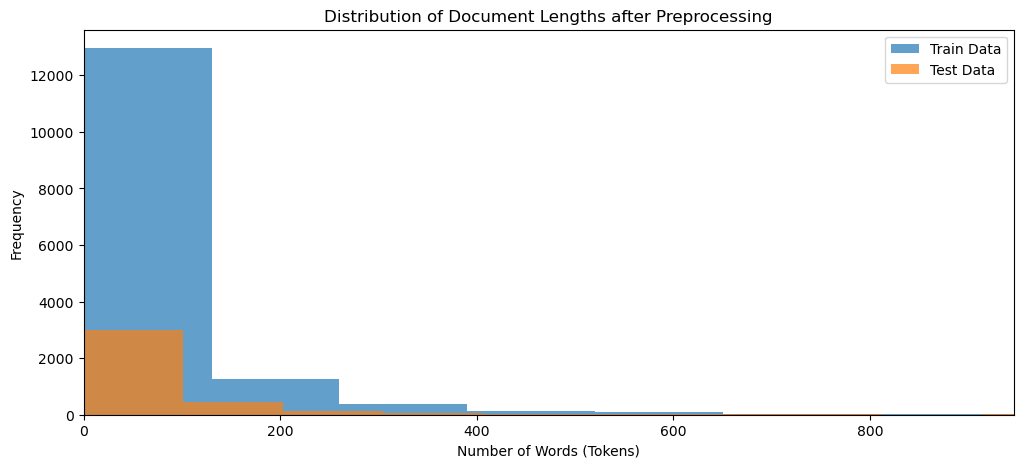

In [11]:
# --- EDA: 문장 길이 분석 ---
train_lengths = [len(tokens) for tokens in train_tokens_list]
test_lengths = [len(tokens) for tokens in test_tokens_list]

print("\n--- 문장 길이 통계 ---")
print(f"훈련 데이터 평균 길이: {np.mean(train_lengths):.2f}")
print(f"훈련 데이터 최대 길이: {np.max(train_lengths)}")
print(f"훈련 데이터 95백분위수: {np.percentile(train_lengths, 95):.2f}")

# --- 시각화 (Histogram) ---
plt.figure(figsize=(12, 5))
plt.hist(train_lengths, bins=50, alpha=0.7, label='Train Data')
plt.hist(test_lengths, bins=50, alpha=0.7, label='Test Data')
plt.xlabel('Number of Words (Tokens)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Document Lengths after Preprocessing')
plt.xlim(0, np.percentile(train_lengths, 99)) # 99% 지점까지만 확대해서 보기
plt.show()

- Step 2-4 (EDA)의 통계 분석 결과:
 - 훈련 데이터 95백분위수 (95th percentile)가 약 279.00
 - 훈련 데이터 최대 길이 (max)는 6505

 - 최대 길이에 맞추면(6505) 대부분의 데이터가 과도한 패딩(0)으로 채워짐.
 - 따라서, 데이터의 95%를 보존하는 279를 기준으로,
 - 짝 여유를 둔 280을 max_len으로 확정함.


In [12]:
#--- 최대 문장 길이 (max_len) 설정 ---

max_len = 280

print(f"최대 문장 길이(max_len)를 {max_len}으로 설정했습니다.")

최대 문장 길이(max_len)를 280으로 설정했습니다.


## 2. 임베딩 적용

### 1) Word2Vec

In [13]:
from gensim.models import Word2Vec

# --- Word2Vec 모델 학습 ---
print("Word2Vec 모델 학습 시작...")

# 주요 파라미터
embedding_dim_w2v = 128  # 각 단어를 몇 차원의 벡터로 만들 것인가
min_word_count = 5     # 최소 5번 이상 등장한 단어만 사전에 포함
context_window = 5     # (window) 주변 몇 개의 단어까지 문맥으로 볼 것인가

# sg=1: Skip-gram 방식 (중심 단어로 주변 단어 예측)
word2vec_model = Word2Vec(
    sentences=train_tokens_list, # 훈련 데이터 (토큰 리스트의 리스트)
    vector_size=embedding_dim_w2v,
    window=context_window,
    min_count=min_word_count,
    sg=1, # 1: Skip-gram (보통 성능이 더 좋음), 0: CBOW
    workers=4 # 학습 시 사용할 CPU 코어 수
)

print("Word2Vec 모델 학습 완료.")

# --- 학습 결과 테스트 ---
# 학습된 단어 사전(vocabulary)의 크기
print(f"학습된 단어 수 (Vocabulary size): {len(word2vec_model.wv.key_to_index)}")

# 'computer'와 가장 유사한 단어 5개 출력
try:
    similar_words = word2vec_model.wv.most_similar('computer', topn=5)
    print("\n'computer'와 유사한 단어:")
    print(similar_words)
except KeyError:
    print("\n'computer' 단어가 사전에 없거나 최소 빈도수 미만입니다.")

Word2Vec 모델 학습 시작...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Word2Vec 모델 학습 완료.
학습된 단어 수 (Vocabulary size): 21976

'computer'와 유사한 단어:
[('visualisation', 0.6692336797714233), ('computing', 0.6532617211341858), ('engineering', 0.6518641710281372), ('itti', 0.6491866707801819), ('shopper', 0.6392751336097717)]


#### (a) Word2Vec 임베딩 행렬 및 사전 생성

In [14]:
import numpy as np

# 1. 단어 -> 인덱스 사전 (word2idx) 생성
word2idx_w2v = {
    '[PAD]': 0,  # 0번 인덱스: 패딩
    '[UNK]': 1,  # 1번 인덱스: 알 수 없는 단어
}

# 2번 인덱스부터 Word2Vec 모델의 단어들로 채우기
for idx, word in enumerate(word2vec_model.wv.index_to_key):
    word2idx_w2v[word] = idx + 2 # 0번, 1번은 PAD/UNK가 사용 중

print(f"[Word2Vec] 총 사전 크기 (PAD, UNK 포함): {len(word2idx_w2v)}개")

# 2. 임베딩 행렬 (Embedding Matrix) 생성
vocab_size_w2v = len(word2idx_w2v)
embedding_dim_w2v = word2vec_model.vector_size # Step 3-1에서 128로 설정됨

# (사전 크기, 임베딩 차원) 크기의 0으로 채워진 행렬 생성
embedding_matrix_w2v = np.zeros((vocab_size_w2v, embedding_dim_w2v))

# UNK 토큰 (인덱스 1)은 랜덤 값으로 초기화
# (나중에 모델이 학습하면서 이 벡터를 업데이트할 수 있음)
embedding_matrix_w2v[1] = np.random.randn(embedding_dim_w2v)

# 3. Word2Vec 모델의 벡터로 행렬 채우기
for word, idx in word2idx_w2v.items():
    if idx < 2:  # PAD(0), UNK(1)는 건너뛰기
        continue
    
    try:
        # Word2Vec 모델에 있는 단어 벡터를 가져와서
        # 우리 행렬의 해당 인덱스에 복사
        vector = word2vec_model.wv[word]
        embedding_matrix_w2v[idx] = vector
    except KeyError:
        # 이 경우는 발생하면 안 되지만, 예방 차원
        continue 

print(f"임베딩 행렬 크기: {embedding_matrix_w2v.shape}")

# (옵션) 'computer' 단어의 인덱스와 벡터 확인
computer_idx = word2idx_w2v.get('computer', 1) # 없으면 1 (UNK)
print(f"'computer'의 인덱스: {computer_idx}")
# 'computer' 인덱스의 벡터 앞 5개 값
print(f"'computer'의 벡터 (일부): {embedding_matrix_w2v[computer_idx][:5]}...")

[Word2Vec] 총 사전 크기 (PAD, UNK 포함): 21978개
임베딩 행렬 크기: (21978, 128)
'computer'의 인덱스: 151
'computer'의 벡터 (일부): [-0.07580339 -0.37074336  0.55698651  0.20242423  0.24500774]...


In [15]:
import torch
from torch.utils.data import Dataset, DataLoader

class TextEmbeddingDataset(Dataset):
    """
    텍스트 데이터를 인덱스 텐서로 변환하고 패딩/트러케이션을 적용하는 Dataset
    """
    def __init__(self, tokens_list, labels, word2idx, max_len):
        self.tokens_list = tokens_list  # 전처리된 토큰 리스트 (e.g., [['i', 'love', 'nlp'], ...])
        self.labels = labels            # 라벨 리스트 (e.g., [0, 1, ...])
        self.word2idx = word2idx        # 단어-인덱스 사전
        self.max_len = max_len          # 최대 길이 (e.g., 280)

    def __len__(self):
        """ 데이터셋의 총 샘플 수 """
        return len(self.labels)

    def __getitem__(self, idx):
        """ idx번째 샘플을 가져오는 함수 """
        
        # 1. idx번째 토큰 리스트 가져오기
        tokens = self.tokens_list[idx]
        
        # 2. 토큰 리스트 -> 인덱스 리스트로 변환
        #    word2idx에 단어가 있으면 해당 인덱스, 없으면 [UNK]의 인덱스(1) 사용
        encoded = [self.word2idx.get(word, 1) for word in tokens]
        
        # 3. 패딩(Padding) / 트러케이션(Truncation)
        if len(encoded) < self.max_len:
            # max_len보다 짧으면, [PAD] 인덱스(0)로 뒤쪽을 채움
            encoded += [0] * (self.max_len - len(encoded))
        else:
            # max_len보다 길면, 앞쪽에서 자름
            encoded = encoded[:self.max_len]
            
        # 4. 리스트를 PyTorch 텐서로 변환
        #    (인덱스 리스트, 라벨) 반환
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

# --- 클래스 정의 확인 ---
print("TextEmbeddingDataset 클래스가 정의되었습니다.")
print("다음 단계에서 이 클래스를 사용해 실제 데이터셋을 만들겠습니다.")

TextEmbeddingDataset 클래스가 정의되었습니다.
다음 단계에서 이 클래스를 사용해 실제 데이터셋을 만들겠습니다.


#### (b) Word2Vec용 Dataset 생성

In [16]:
# 1. Word2Vec 훈련 데이터셋 생성
train_dataset_w2v = TextEmbeddingDataset(
    tokens_list=train_tokens_list,
    labels=train_labels,
    word2idx=word2idx_w2v,
    max_len=max_len # 280
)

# 2. Word2Vec 테스트 데이터셋 생성
test_dataset_w2v = TextEmbeddingDataset(
    tokens_list=test_tokens_list,
    labels=test_labels,
    word2idx=word2idx_w2v,
    max_len=max_len # 280
)

print("Word2Vec용 훈련 및 테스트 Dataset 생성 완료.")

# --- 작동 테스트: 0번째 훈련 데이터 확인 ---
# train_dataset_w2v[0]을 호출하면 __getitem__(0)이 실행됨
sample_encoded, sample_label = train_dataset_w2v[0]

print(f"\n--- 0번째 훈련 샘플 테스트 ---")
print(f"인코딩된 텐서 (일부): {sample_encoded[:20]}...") # 280개 중 앞 20개
print(f"텐서 길이: {sample_encoded.shape}") # [280]
print(f"라벨: {sample_label}") # 텐서(숫자)

Word2Vec용 훈련 및 테스트 Dataset 생성 완료.

--- 0번째 훈련 샘플 테스트 ---
인코딩된 텐서 (일부): tensor([  54, 1631, 1244,  139,   56,  385,  269,  568, 1044, 2852,  114,  139,
         597,  441,  177, 1191,  114,  353,   16,  210])...
텐서 길이: torch.Size([280])
라벨: 5


In [17]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

# 1. Word2Vec 훈련 데이터로더 생성
train_loader_w2v = DataLoader(
    dataset=train_dataset_w2v,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # 
)

# 2. Word2Vec 테스트 데이터로더 생성
test_loader_w2v = DataLoader(
    dataset=test_dataset_w2v,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0  # 
)

print(f"Word2Vec용 훈련 및 테스트 DataLoader 생성 완료. (num_workers=0)")
print(f"배치 크기: {BATCH_SIZE}")

# --- 작동 테스트: 훈련 로더에서 1배치 꺼내보기 ---
# (이제 에러 없이 실행되어야 합니다)
sample_batch_inputs, sample_batch_labels = next(iter(train_loader_w2v))

print("\n--- 첫 번째 배치(Batch) 테스트 ---")
print(f"입력 데이터 텐서 크기: {sample_batch_inputs.shape}")
print(f"라벨 데이터 텐서 크기: {sample_batch_labels.shape}")

Word2Vec용 훈련 및 테스트 DataLoader 생성 완료. (num_workers=0)
배치 크기: 64

--- 첫 번째 배치(Batch) 테스트 ---
입력 데이터 텐서 크기: torch.Size([64, 280])
라벨 데이터 텐서 크기: torch.Size([64])


In [18]:
import torch.nn as nn

class TextClassifierRNN(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, n_layers=2, bidirectional=True, dropout=0.5):
        super(TextClassifierRNN, self).__init__()
        
        vocab_size, embedding_dim = embedding_matrix.shape
        
        # 1. 임베딩 층
        #    from_pretrained: 우리가 만든 행렬로 가중치를 '미리 채워넣음'
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=False # <--- False로 설정, 학습 중에 벡터가 미세 조정(fine-tuning) 됨
        )
        
        # 2. LSTM 층
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True # <--- 입력 텐서 형식을 [배치 크기, 시퀀스 길이]로 받음
        )
        
        # 3. 분류기 (Linear) 층
        #    양방향(bidirectional)이므로, LSTM의 hidden_dim * 2를 입력으로 받음
        self.fc = nn.Linear(
            hidden_dim * 2 if bidirectional else hidden_dim, 
            output_dim
        )
        
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch_size, max_len] (e.g., [64, 280])
        
        # 1. 임베딩
        # embedded: [batch_size, max_len, embedding_dim] (e.g., [64, 280, 128])
        embedded = self.embedding(x)
        
        # 2. LSTM
        # outputs: 모든 시점(단어)의 출력값 (우리는 사용 안 함)
        # (hidden, cell): (마지막 시점의) 은닉 상태와 셀 상태
        # hidden: [n_layers * n_directions, batch_size, hidden_dim] (e.g., [4, 64, 256])
        _ , (hidden, cell) = self.lstm(embedded)
        
        # 3. 마지막 은닉 상태(hidden state) 추출
        # 양방향(bidirectional=True)의 경우:
        # hidden[-2] : 마지막 레이어의 '정방향' hidden state
        # hidden[-1] : 마지막 레이어의 '역방향' hidden state
        # 이 둘을 연결(concatenate)함
        
        # hidden: [batch_size, hidden_dim * 2]
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        # 4. 분류기 통과
        output = self.fc(self.dropout(hidden_cat))
        
        # output: [batch_size, output_dim] (e.g., [64, 20])
        return output

# --- 클래스 정의 확인 ---
print("TextClassifierRNN 클래스가 정의되었습니다.")
print("다음 단계에서 이 클래스를 사용해 실제 모델을 만들겠습니다.")

TextClassifierRNN 클래스가 정의되었습니다.
다음 단계에서 이 클래스를 사용해 실제 모델을 만들겠습니다.


In [19]:
import torch.nn as nn

class TextClassifierRNN(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, n_layers=2, bidirectional=True, dropout=0.5):
        super(TextClassifierRNN, self).__init__()
        
        vocab_size, embedding_dim = embedding_matrix.shape
        
        # 1. 임베딩 층
        #    from_pretrained: 우리가 만든 행렬로 가중치를 '미리 채워넣음'
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embedding_matrix, dtype=torch.float),
            freeze=False # <--- False로 설정, 학습 중에 벡터가 미세 조정(fine-tuning) 됨
        )
        
        # 2. LSTM 층
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            bidirectional=bidirectional,
            dropout=dropout if n_layers > 1 else 0,
            batch_first=True # <--- 입력 텐서 형식을 [배치 크기, 시퀀스 길이]로 받음
        )
        
        # 3. 분류기 (Linear) 층
        #    양방향(bidirectional)이므로, LSTM의 hidden_dim * 2를 입력으로 받음
        self.fc = nn.Linear(
            hidden_dim * 2 if bidirectional else hidden_dim, 
            output_dim
        )
        
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: [batch_size, max_len] (e.g., [64, 280])
        
        # 1. 임베딩
        # embedded: [batch_size, max_len, embedding_dim] (e.g., [64, 280, 128])
        embedded = self.embedding(x)
        
        # 2. LSTM
        # outputs: 모든 시점(단어)의 출력값 (우리는 사용 안 함)
        # (hidden, cell): (마지막 시점의) 은닉 상태와 셀 상태
        # hidden: [n_layers * n_directions, batch_size, hidden_dim] (e.g., [4, 64, 256])
        _ , (hidden, cell) = self.lstm(embedded)
        
        # 3. 마지막 은닉 상태(hidden state) 추출
        # 양방향(bidirectional=True)의 경우:
        # hidden[-2] : 마지막 레이어의 '정방향' hidden state
        # hidden[-1] : 마지막 레이어의 '역방향' hidden state
        # 이 둘을 연결(concatenate)함
        
        # hidden: [batch_size, hidden_dim * 2]
        hidden_cat = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        # 4. 분류기 통과
        output = self.fc(self.dropout(hidden_cat))
        
        # output: [batch_size, output_dim] (e.g., [64, 20])
        return output

# --- 클래스 정의 확인 ---
print("TextClassifierRNN 클래스가 정의되었습니다.")
print("다음 단계에서 이 클래스를 사용해 실제 모델을 만들겠습니다.")

TextClassifierRNN 클래스가 정의되었습니다.
다음 단계에서 이 클래스를 사용해 실제 모델을 만들겠습니다.


In [20]:
import torch.optim as optim

# --- 1. 하이퍼파라미터 설정 ---
HIDDEN_DIM = 128         # LSTM의 은닉층 크기
OUTPUT_DIM = len(label_names) # 클래스 개수 (20개)
N_LAYERS = 2             # LSTM 레이어 수
DROPOUT = 0.5            # 드롭아웃 비율

# --- 2. 모델 인스턴스화 (Word2Vec) ---
model_w2v = TextClassifierRNN(
    embedding_matrix=embedding_matrix_w2v, # Step 3-2에서 만든 행렬
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
)

# 모델을 device (MPS/CUDA/CPU)로 이동
model_w2v.to(device)

# --- 3. 손실 함수 (Loss Function) 정의 ---
# 다중 클래스 분류(CrossEntropyLoss)는 내부에 Softmax를 포함하고 있음
loss_fn = nn.CrossEntropyLoss()

# --- 4. 옵티마이저 (Optimizer) 정의 ---
# model_w2v.parameters(): 모델이 학습해야 할 모든 가중치
# lr=0.001: Learning Rate (학습률)
optimizer_w2v = optim.Adam(model_w2v.parameters(), lr=0.001)

print("Word2Vec 모델, 손실 함수, 옵티마이저 정의 완료.")

# (옵션) 모델 구조 확인
print("\n--- 모델 구조 (model_w2v) ---")
print(model_w2v)

Word2Vec 모델, 손실 함수, 옵티마이저 정의 완료.

--- 모델 구조 (model_w2v) ---
TextClassifierRNN(
  (embedding): Embedding(21978, 128)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=256, out_features=20, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [21]:
import torch.nn.functional as F

# (Step 5-2에서 정의했지만, 명시적으로 재확인)
# device = torch.device("mps" or "cuda" or "cpu")
# loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, loader, optimizer, loss_fn):
    """
    1 에포크(epoch) 동안 모델을 훈련시키는 함수
    """
    model.train() # 모델을 훈련 모드로 설정
    total_loss = 0
    
    # DataLoader에서 배치(batch) 단위로 데이터 로드
    for inputs, labels in loader:
        # 데이터를 설정한 device로 이동
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # 1. 옵티마이저 기울기 초기화
        optimizer.zero_grad()
        
        # 2. 모델 순전파 (Forward pass)
        outputs = model(inputs)
        
        # 3. 손실(Loss) 계산
        loss = loss_fn(outputs, labels)
        
        # 4. 역전파 (Backward pass)
        loss.backward()
        
        # 5. 모델 가중치 업데이트
        optimizer.step()
        
        total_loss += loss.item()
        
    # 1 에포크의 평균 손실 반환
    return total_loss / len(loader)

def evaluate_model(model, loader, loss_fn):
    """
    모델을 평가(accuracy)하는 함수
    """
    model.eval() # 모델을 평가 모드로 설정
    total_loss = 0
    correct_predictions = 0
    
    # 기울기 계산 중지 (메모리 절약, 속도 향상)
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # 모델 순전파
            outputs = model(inputs)
            
            # 손실 계산
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()
            
            # 정확도 계산
            # outputs: [batch_size, 20] -> 가장 큰 값의 '인덱스'를 예측으로 간주
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()
            
    avg_loss = total_loss / len(loader)
    accuracy = correct_predictions / len(loader.dataset) # (중요) 배치 개수가 아닌 '총 데이터 개수'로 나눠야 함
    
    return avg_loss, accuracy

# --- 함수 정의 확인 ---
print("train_epoch 및 evaluate_model 함수가 정의되었습니다.")
print("다음 단계에서 이 함수들을 호출하여 실제 학습을 시작하겠습니다.")

train_epoch 및 evaluate_model 함수가 정의되었습니다.
다음 단계에서 이 함수들을 호출하여 실제 학습을 시작하겠습니다.


In [22]:
import time

N_EPOCHS = 10 # 총 10번 반복 학습

# 훈련/평가 결과를 저장할 리스트
train_losses = []
test_losses = []
test_accuracies = []

print(f"--- Word2Vec 모델({device}) 학습 시작 ---")
print(f"총 에포크: {N_EPOCHS}")

for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    # 1. 훈련
    train_loss = train_epoch(
        model=model_w2v, 
        loader=train_loader_w2v, 
        optimizer=optimizer_w2v, 
        loss_fn=loss_fn
    )
    
    # 2. 평가
    test_loss, test_accuracy = evaluate_model(
        model=model_w2v, 
        loader=test_loader_w2v, 
        loss_fn=loss_fn
    )
    
    end_time = time.time()
    
    # 3. 결과 저장
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)
    
    # 4. 결과 출력
    print(f"\nEpoch {epoch+1:02}/{N_EPOCHS} | 시간: {end_time - start_time:.2f}초")
    print(f"\t [Train] Loss: {train_loss:.4f}")
    print(f"\t [Test]  Loss: {test_loss:.4f} | Accuracy: {test_accuracy*100:.2f}%")

print("\n--- 학습 완료 ---")
print(f"최종 테스트 정확도: {test_accuracies[-1]*100:.2f}%")

--- Word2Vec 모델(cpu) 학습 시작 ---
총 에포크: 10

Epoch 01/10 | 시간: 133.17초
	 [Train] Loss: 2.2349
	 [Test]  Loss: 2.0259 | Accuracy: 30.77%

Epoch 02/10 | 시간: 135.39초
	 [Train] Loss: 1.6424
	 [Test]  Loss: 1.5197 | Accuracy: 48.17%

Epoch 03/10 | 시간: 134.44초
	 [Train] Loss: 1.3354
	 [Test]  Loss: 1.4393 | Accuracy: 50.24%

Epoch 04/10 | 시간: 130.37초
	 [Train] Loss: 1.1088
	 [Test]  Loss: 1.3320 | Accuracy: 56.05%

Epoch 05/10 | 시간: 125.42초
	 [Train] Loss: 0.9229
	 [Test]  Loss: 1.2970 | Accuracy: 59.71%

Epoch 06/10 | 시간: 125.48초
	 [Train] Loss: 0.7593
	 [Test]  Loss: 1.3220 | Accuracy: 60.16%

Epoch 07/10 | 시간: 126.20초
	 [Train] Loss: 0.6654
	 [Test]  Loss: 1.3095 | Accuracy: 61.86%

Epoch 08/10 | 시간: 126.70초
	 [Train] Loss: 0.5781
	 [Test]  Loss: 1.3704 | Accuracy: 63.58%

Epoch 09/10 | 시간: 134.34초
	 [Train] Loss: 0.4891
	 [Test]  Loss: 1.4246 | Accuracy: 62.36%

Epoch 10/10 | 시간: 133.66초
	 [Train] Loss: 0.4169
	 [Test]  Loss: 1.5168 | Accuracy: 63.58%

--- 학습 완료 ---
최종 테스트 정확도: 63.58%


### 2) FastText

In [23]:
from gensim.models import FastText

# --- FastText 모델 학습 ---
print("FastText 모델 학습 시작...")

# Word2Vec과 동일한 파라미터 사용 (비교를 위해)
embedding_dim_ft = 128  # 128차원 벡터
min_word_count = 5     # 최소 5회 등장
context_window = 5     # 문맥 창

# sg=1: Skip-gram 방식
fasttext_model = FastText(
    sentences=train_tokens_list, # 동일한 훈련 데이터 사용
    vector_size=embedding_dim_ft,
    window=context_window,
    min_count=min_word_count,
    sg=1,
    workers=4
)

print("FastText 모델 학습 완료.")

# --- 학습 결과 테스트 ---
print(f"학습된 단어 수 (Vocabulary size): {len(fasttext_model.wv.key_to_index)}")

# 'computer'와 유사한 단어
try:
    similar_words_ft = fasttext_model.wv.most_similar('computer', topn=5)
    print("\n'computer'와 유사한 단어 (FastText):")
    print(similar_words_ft)
except KeyError:
    print("\n'computer' 단어가 사전에 없거나 최소 빈도수 미만입니다.")

FastText 모델 학습 시작...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


FastText 모델 학습 완료.
학습된 단어 수 (Vocabulary size): 21976

'computer'와 유사한 단어 (FastText):
[('compute', 0.9230598211288452), ('computers', 0.9230226278305054), ('microcomputer', 0.9114627242088318), ('supercomputer', 0.88555508852005), ('computes', 0.8853572010993958)]


#### (a) FastText 임베딩 행렬 및 사전 생성

In [39]:
import numpy as np

# 1. 단어 -> 인덱스 사전 (word2idx) 생성
word2idx_ft = {
    '[PAD]': 0,  # 0번 인덱스: 패딩
    '[UNK]': 1,  # 1번 인덱스: 알 수 없는 단어
}

# 2번 인덱스부터 FastText 모델의 단어들로 채우기
for idx, word in enumerate(fasttext_model.wv.index_to_key):
    word2idx_ft[word] = idx + 2

print(f"[FastText] 총 사전 크기 (PAD, UNK 포함): {len(word2idx_ft)}개")

# 2. 임베딩 행렬 (Embedding Matrix) 생성
vocab_size_ft = len(word2idx_ft)
embedding_dim_ft = fasttext_model.vector_size # Step 3-3에서 128로 설정됨

embedding_matrix_ft = np.zeros((vocab_size_ft, embedding_dim_ft))

# UNK 토큰 (인덱스 1)은 랜덤 값으로 초기화
embedding_matrix_ft[1] = np.random.randn(embedding_dim_ft)

# 3. FastText 모델의 벡터로 행렬 채우기
for word, idx in word2idx_ft.items():
    if idx < 2:  # PAD(0), UNK(1)는 건너뛰기
        continue
    
    try:
        vector = fasttext_model.wv[word]
        embedding_matrix_ft[idx] = vector
    except KeyError:
        continue 

print(f"임베딩 행렬 크기: {embedding_matrix_ft.shape}")

[FastText] 총 사전 크기 (PAD, UNK 포함): 21978개
임베딩 행렬 크기: (21978, 128)


#### (b) FastText용 Dataset 생성

In [41]:
# 1. FastText 훈련 데이터셋 생성
# (TextEmbeddingDataset 클래스는 Step 4-1에서 이미 정의됨)
train_dataset_ft = TextEmbeddingDataset(
    tokens_list=train_tokens_list,
    labels=train_labels,
    word2idx=word2idx_ft, # <--- FastText용 사전 사용
    max_len=max_len # 280
)

# 2. FastText 테스트 데이터셋 생성
test_dataset_ft = TextEmbeddingDataset(
    tokens_list=test_tokens_list,
    labels=test_labels,
    word2idx=word2idx_ft, # <--- FastText용 사전 사용
    max_len=max_len # 280
)

print("FastText용 훈련 및 테스트 Dataset 생성 완료.")

# --- 작동 테스트: 0번째 훈련 데이터 확인 ---
sample_encoded, sample_label = train_dataset_ft[0]

print(f"\n--- 0번째 훈련 샘플 테스트 ---")
print(f"인코딩된 텐서 (일부): {sample_encoded[:20]}...")
print(f"텐서 길이: {sample_encoded.shape}") # [280]
print(f"라벨: {sample_label}")

FastText용 훈련 및 테스트 Dataset 생성 완료.

--- 0번째 훈련 샘플 테스트 ---
인코딩된 텐서 (일부): tensor([  54, 1631, 1244,  139,   56,  385,  269,  568, 1044, 2852,  114,  139,
         597,  441,  177, 1191,  114,  353,   16,  210])...
텐서 길이: torch.Size([280])
라벨: 5


#### (c) FastText용 DataLoader 생성

In [42]:
from torch.utils.data import DataLoader

# BATCH_SIZE는 Step 4-3에서 64로 정의됨 (다시 정의해도 무방)
BATCH_SIZE = 64

# 1. FastText 훈련 데이터로더 생성
train_loader_ft = DataLoader(
    dataset=train_dataset_ft,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # (병렬 처리 끔)
)

# 2. FastText 테스트 데이터로더 생성
test_loader_ft = DataLoader(
    dataset=test_dataset_ft,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"FastText용 훈련 및 테스트 DataLoader 생성 완료.")

# --- 작동 테스트: 훈련 로더에서 1배치 꺼내보기 ---
sample_batch_inputs, sample_batch_labels = next(iter(train_loader_ft))

print("\n--- 첫 번째 배치(Batch) 테스트 ---")
print(f"입력 데이터 텐서 크기: {sample_batch_inputs.shape}")
print(f"라벨 데이터 텐서 크기: {sample_batch_labels.shape}")

FastText용 훈련 및 테스트 DataLoader 생성 완료.

--- 첫 번째 배치(Batch) 테스트 ---
입력 데이터 텐서 크기: torch.Size([64, 280])
라벨 데이터 텐서 크기: torch.Size([64])


In [43]:
import torch.optim as optim
import torch.nn as nn # (이미 import되었지만, 명시적으로 재확인)

# --- 1. 하이퍼파라미터 (Step 5-2와 동일) ---
HIDDEN_DIM = 128
OUTPUT_DIM = len(label_names) # 20
N_LAYERS = 2
DROPOUT = 0.5

# --- 2. 모델 인스턴스화 (FastText) ---
model_ft = TextClassifierRNN(
    embedding_matrix=embedding_matrix_ft, # <--- FastText 임베딩 행렬 사용
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
)

# 모델을 device (MPS/CUDA/CPU)로 이동
model_ft.to(device)

# --- 3. 손실 함수 (Loss Function) 재사용 ---
# loss_fn = nn.CrossEntropyLoss() # (Step 5-2에서 이미 정의됨)

# --- 4. 옵티마이저 (Optimizer) 새로 정의 ---
# model_ft의 파라미터를 학습하는 별도의 옵티마이저
optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.001)

print("FastText 모델, 손실 함수, 옵티마이저 정의 완료.")

# (옵션) 모델 구조 확인
print("\n--- 모델 구조 (model_ft) ---")
print(model_ft)

FastText 모델, 손실 함수, 옵티마이저 정의 완료.

--- 모델 구조 (model_ft) ---
TextClassifierRNN(
  (embedding): Embedding(21978, 128)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=256, out_features=20, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


#### (d) FastText 모델 학습 루프 실행

In [44]:
import time

# N_EPOCHS는 Step 6-2에서 10으로 정의됨
# (N_EPOCHS = 10)

# FastText 결과를 저장할 리스트
ft_train_losses = []
ft_test_losses = []
ft_test_accuracies = []

print(f"--- FastText 모델({device}) 학습 시작 ---")
print(f"총 에포크: {N_EPOCHS}")

for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    # 1. 훈련 (FastText 모델과 로더, 옵티마이저 사용)
    train_loss_ft = train_epoch(
        model=model_ft, 
        loader=train_loader_ft, 
        optimizer=optimizer_ft, 
        loss_fn=loss_fn
    )
    
    # 2. 평가
    test_loss_ft, test_accuracy_ft = evaluate_model(
        model=model_ft, 
        loader=test_loader_ft, 
        loss_fn=loss_fn
    )
    
    end_time = time.time()
    
    # 3. 결과 저장
    ft_train_losses.append(train_loss_ft)
    ft_test_losses.append(test_loss_ft)
    ft_test_accuracies.append(test_accuracy_ft)
    
    # 4. 결과 출력
    print(f"\nEpoch {epoch+1:02}/{N_EPOCHS} | 시간: {end_time - start_time:.2f}초")
    print(f"\t [Train] Loss: {train_loss_ft:.4f}")
    print(f"\t [Test]  Loss: {test_loss_ft:.4f} | Accuracy: {test_accuracy_ft*100:.2f}%")

print("\n--- 학습 완료 ---")
print(f"최종 테스트 정확도 (FastText): {ft_test_accuracies[-1]*100:.2f}%")

--- FastText 모델(mps) 학습 시작 ---
총 에포크: 10

Epoch 01/10 | 시간: 18.78초
	 [Train] Loss: 2.2436
	 [Test]  Loss: 2.1885 | Accuracy: 27.61%

Epoch 02/10 | 시간: 18.53초
	 [Train] Loss: 1.7224
	 [Test]  Loss: 1.6894 | Accuracy: 41.41%

Epoch 03/10 | 시간: 18.65초
	 [Train] Loss: 1.3959
	 [Test]  Loss: 1.4191 | Accuracy: 51.14%

Epoch 04/10 | 시간: 18.55초
	 [Train] Loss: 1.1492
	 [Test]  Loss: 1.3422 | Accuracy: 55.36%

Epoch 05/10 | 시간: 18.58초
	 [Train] Loss: 0.9767
	 [Test]  Loss: 1.3379 | Accuracy: 57.27%

Epoch 06/10 | 시간: 18.65초
	 [Train] Loss: 0.8313
	 [Test]  Loss: 1.3096 | Accuracy: 60.08%

Epoch 07/10 | 시간: 18.69초
	 [Train] Loss: 0.7313
	 [Test]  Loss: 1.3127 | Accuracy: 60.42%

Epoch 08/10 | 시간: 18.66초
	 [Train] Loss: 0.6030
	 [Test]  Loss: 1.4033 | Accuracy: 60.90%

Epoch 09/10 | 시간: 18.60초
	 [Train] Loss: 0.5267
	 [Test]  Loss: 1.4190 | Accuracy: 62.39%

Epoch 10/10 | 시간: 18.53초
	 [Train] Loss: 0.4653
	 [Test]  Loss: 1.4437 | Accuracy: 62.52%

--- 학습 완료 ---
최종 테스트 정확도 (FastText): 62.52%


### (3) Glove

- 훨씬 더 거대한 데이터(e.g., 위키피디아, 인터넷 전체)로 미리 학습시켜 놓은 '기성품' 임베딩

In [24]:
import os
import zipfile
import numpy as np

# 사용할 파일과 차원 정의
GLOVE_FILE = "glove.6B.100d.txt" 
embedding_dim_glove = 100

if not os.path.exists(GLOVE_FILE):
    # 1. urllib 대신 !wget 사용 (진행률 표시됨)
    print("!wget으로 GloVe 임베딩 파일 다운로드 중 (약 822MB)...")
    !wget https://nlp.stanford.edu/data/glove.6B.zip -O glove.6B.zip
    
    print("압축 해제 중...")
    with zipfile.ZipFile("glove.6B.zip", 'r') as zip_ref:
        # 100d 파일만 압축 해제
        zip_ref.extract(GLOVE_FILE) 
        # (만약 100d만 푸는 게 실패하면 .extractall()을 사용)
    
    print("다운로드 및 압축 해제 완료.")
    os.remove("glove.6B.zip") # zip 파일 삭제
else:
    print("GloVe 파일이 이미 존재합니다.")

# --- 2. GloVe 파일 로드 (이전과 동일) ---
print(f"{GLOVE_FILE} 파일 로딩 중...")
glove_embeddings = {} 

with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = coeffs

print(f"GloVe 로딩 완료. 총 {len(glove_embeddings)}개 단어 벡터 로드됨.")

# --- 작동 테스트 (이전과 동일) ---
try:
    print(f"'computer'의 GloVe 벡터 (일부): {glove_embeddings['computer'][:5]}...")
except KeyError:
    print("'computer' 단어가 GloVe 사전에 없습니다.")

GloVe 파일이 이미 존재합니다.
glove.6B.100d.txt 파일 로딩 중...
GloVe 로딩 완료. 총 400000개 단어 벡터 로드됨.
'computer'의 GloVe 벡터 (일부): [-0.16298   0.30141   0.57978   0.066548  0.45835 ]...


In [25]:
import numpy as np
from collections import Counter

# 1. 우리 훈련 데이터(train_tokens_list) 기준 사전 구축
print("train_tokens_list 기준으로 사전 구축 중...")
word_counts = Counter()
for tokens in train_tokens_list:
    word_counts.update(tokens)

# 최소 5번 이상 등장한 단어만 사용 (min_count=5)
# (W2V/FT와 동일 조건)
vocab_glove = [word for word, count in word_counts.items() if count >= 5]

# 2. 단어 -> 인덱스 사전 (word2idx) 생성
word2idx_glove = {
    '[PAD]': 0,
    '[UNK]': 1,
}
# 2번 인덱스부터 우리 사전(vocab_glove)의 단어들로 채우기
for idx, word in enumerate(vocab_glove):
    word2idx_glove[word] = idx + 2

print(f"[GloVe] 총 사전 크기 (PAD, UNK 포함): {len(word2idx_glove)}개")

# 3. 임베딩 행렬 (Embedding Matrix) 생성
vocab_size_glove = len(word2idx_glove)
# embedding_dim_glove = 100 (Step 3-5에서 설정됨)

# (사전 크기, 100) 크기의 0 행렬 생성
embedding_matrix_glove = np.zeros((vocab_size_glove, embedding_dim_glove))

# UNK 토큰(1번)은 랜덤 값으로 초기화
embedding_matrix_glove[1] = np.random.randn(embedding_dim_glove)

# 4. GloVe 벡터로 행렬 채우기
unknown_word_count = 0
for word, idx in word2idx_glove.items():
    if idx < 2: # PAD(0), UNK(1) 건너뛰기
        continue
    
    # GloVe 딕셔너리(glove_embeddings)에 단어가 있는지 확인
    embedding_vector = glove_embeddings.get(word)
    
    if embedding_vector is not None:
        # Case 1: GloVe에 단어가 있음 -> 벡터 복사
        embedding_matrix_glove[idx] = embedding_vector
    else:
        # Case 2: GloVe에 단어가 없음 (우리 데이터엔 OOV)
        # -> 랜덤 벡터로 초기화 (UNK와 동일 취급)
        embedding_matrix_glove[idx] = np.random.randn(embedding_dim_glove)
        unknown_word_count += 1

print(f"임베딩 행렬 크기: {embedding_matrix_glove.shape}")
print(f"GloVe에 포함되지 않은 단어 수: {unknown_word_count} / {len(vocab_glove)}개")

train_tokens_list 기준으로 사전 구축 중...
[GloVe] 총 사전 크기 (PAD, UNK 포함): 21978개
임베딩 행렬 크기: (21978, 100)
GloVe에 포함되지 않은 단어 수: 2082 / 21976개


In [26]:
# 1. GloVe 훈련 데이터셋 생성
# (TextEmbeddingDataset 클래스는 Step 4-1에서 이미 정의됨)
train_dataset_glove = TextEmbeddingDataset(
    tokens_list=train_tokens_list,
    labels=train_labels,
    word2idx=word2idx_glove, # <--- GloVe용 사전 사용
    max_len=max_len # 280
)

# 2. GloVe 테스트 데이터셋 생성
test_dataset_glove = TextEmbeddingDataset(
    tokens_list=test_tokens_list,
    labels=test_labels,
    word2idx=word2idx_glove, # <--- GloVe용 사전 사용
    max_len=max_len # 280
)

print("GloVe용 훈련 및 테스트 Dataset 생성 완료.")

# --- 작동 테스트: 0번째 훈련 데이터 확인 ---
sample_encoded, sample_label = train_dataset_glove[0]

print(f"\n--- 0번째 훈련 샘플 테스트 ---")
print(f"인코딩된 텐서 (일부): {sample_encoded[:20]}...")
print(f"텐서 길이: {sample_encoded.shape}") # [280]
print(f"라벨: {sample_label}")

GloVe용 훈련 및 테스트 Dataset 생성 완료.

--- 0번째 훈련 샘플 테스트 ---
인코딩된 텐서 (일부): tensor([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  5, 13, 14, 15, 16, 12, 17,
        18, 19])...
텐서 길이: torch.Size([280])
라벨: 5


In [27]:
from torch.utils.data import DataLoader

# BATCH_SIZE는 64로 이전에 정의되었습니다.
# (BATCH_SIZE = 64)

# 1. GloVe 훈련 데이터로더 생성
train_loader_glove = DataLoader(
    dataset=train_dataset_glove,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # (병렬 처리 끔)
)

# 2. GloVe 테스트 데이터로더 생성
test_loader_glove = DataLoader(
    dataset=test_dataset_glove,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"GloVe용 훈련 및 테스트 DataLoader 생성 완료.")

# --- 작동 테스트: 훈련 로더에서 1배치 꺼내보기 ---
sample_batch_inputs, sample_batch_labels = next(iter(train_loader_glove))

print("\n--- 첫 번째 배치(Batch) 테스트 ---")
print(f"입력 데이터 텐서 크기: {sample_batch_inputs.shape}")
print(f"라벨 데이터 텐서 크기: {sample_batch_labels.shape}")

GloVe용 훈련 및 테스트 DataLoader 생성 완료.

--- 첫 번째 배치(Batch) 테스트 ---
입력 데이터 텐서 크기: torch.Size([64, 280])
라벨 데이터 텐서 크기: torch.Size([64])


In [28]:
import torch.optim as optim
import torch.nn as nn # (이미 import되었지만, 명시적으로 재확인)

# --- 1. 하이퍼파라미터 (Step 5-2/5-3과 동일) ---
HIDDEN_DIM = 128         # LSTM 은닉층 크기는 128로 유지
OUTPUT_DIM = len(label_names) # 20
N_LAYERS = 2
DROPOUT = 0.5

# --- 2. 모델 인스턴스화 (GloVe) ---
model_glove = TextClassifierRNN(
    embedding_matrix=embedding_matrix_glove, # <--- GloVe 임베딩 행렬 사용
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    n_layers=N_LAYERS,
    dropout=DROPOUT
)

# 모델을 device (MPS/CUDA/CPU)로 이동
model_glove.to(device)

# --- 3. 손실 함수 (Loss Function) 재사용 ---
# loss_fn = nn.CrossEntropyLoss() # (이전에 이미 정의됨)

# --- 4. 옵티마이저 (Optimizer) 새로 정의 ---
optimizer_glove = optim.Adam(model_glove.parameters(), lr=0.001)

print("GloVe 모델, 손실 함수, 옵티마이저 정의 완료.")

# (옵션) 모델 구조 확인
print("\n--- 모델 구조 (model_glove) ---")
print(model_glove)

GloVe 모델, 손실 함수, 옵티마이저 정의 완료.

--- 모델 구조 (model_glove) ---
TextClassifierRNN(
  (embedding): Embedding(21978, 100)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=256, out_features=20, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [29]:
import time

# N_EPOCHS는 Step 6-2에서 10으로 정의됨
# (N_EPOCHS = 10)

# GloVe 결과를 저장할 리스트
glove_train_losses = []
glove_test_losses = []
glove_test_accuracies = []

print(f"--- GloVe 모델({device}) 학습 시작 ---")
print(f"총 에포크: {N_EPOCHS}")

for epoch in range(N_EPOCHS):
    start_time = time.time()
    
    # 1. 훈련 (GloVe 모델과 로더, 옵티마이저 사용)
    train_loss_glove = train_epoch(
        model=model_glove, 
        loader=train_loader_glove, 
        optimizer=optimizer_glove, 
        loss_fn=loss_fn
    )
    
    # 2. 평가
    test_loss_glove, test_accuracy_glove = evaluate_model(
        model=model_glove, 
        loader=test_loader_glove, 
        loss_fn=loss_fn
    )
    
    end_time = time.time()
    
    # 3. 결과 저장
    glove_train_losses.append(train_loss_glove)
    glove_test_losses.append(test_loss_glove)
    glove_test_accuracies.append(test_accuracy_glove)
    
    # 4. 결과 출력
    print(f"\nEpoch {epoch+1:02}/{N_EPOCHS} | 시간: {end_time - start_time:.2f}초")
    print(f"\t [Train] Loss: {train_loss_glove:.4f}")
    print(f"\t [Test]  Loss: {test_loss_glove:.4f} | Accuracy: {test_accuracy_glove*100:.2f}%")

print("\n--- 학습 완료 ---")
print(f"최종 테스트 정확도 (GloVe): {glove_test_accuracies[-1]*100:.2f}%")

--- GloVe 모델(cpu) 학습 시작 ---
총 에포크: 10

Epoch 01/10 | 시간: 124.58초
	 [Train] Loss: 2.3095
	 [Test]  Loss: 1.8921 | Accuracy: 35.36%

Epoch 02/10 | 시간: 122.68초
	 [Train] Loss: 1.7136
	 [Test]  Loss: 1.6285 | Accuracy: 43.55%

Epoch 03/10 | 시간: 122.97초
	 [Train] Loss: 1.4491
	 [Test]  Loss: 1.5375 | Accuracy: 47.27%

Epoch 04/10 | 시간: 123.35초
	 [Train] Loss: 1.2712
	 [Test]  Loss: 1.3569 | Accuracy: 54.99%

Epoch 05/10 | 시간: 123.43초
	 [Train] Loss: 1.0817
	 [Test]  Loss: 1.3188 | Accuracy: 57.16%

Epoch 06/10 | 시간: 125.44초
	 [Train] Loss: 0.9305
	 [Test]  Loss: 1.2870 | Accuracy: 59.39%

Epoch 07/10 | 시간: 125.99초
	 [Train] Loss: 0.8086
	 [Test]  Loss: 1.2860 | Accuracy: 61.35%

Epoch 08/10 | 시간: 127.00초
	 [Train] Loss: 0.7266
	 [Test]  Loss: 1.2753 | Accuracy: 63.24%

Epoch 09/10 | 시간: 125.95초
	 [Train] Loss: 0.6327
	 [Test]  Loss: 1.2971 | Accuracy: 63.61%

Epoch 10/10 | 시간: 126.95초
	 [Train] Loss: 0.5352
	 [Test]  Loss: 1.3735 | Accuracy: 63.87%

--- 학습 완료 ---
최종 테스트 정확도 (GloVe): 63.87%


## 3. 비교

In [33]:
# (N_EPOCHS = 10 으로 가정)

# 1. Word2Vec 훈련 결과 (로그 기반)
w2v_acc_percent = [30.77, 48.17, 50.24, 56.05, 59.71, 60.16, 61.86, 63.58, 62.36, 63.58]
test_accuracies = [acc / 100.0 for acc in w2v_acc_percent]

# 2. FastText 훈련 결과 (로그 기반)
# (중복 로그 중 마지막 10개 사용)
ft_acc_percent = [27.61, 41.41, 51.14, 55.36, 57.27, 60.08, 60.42, 60.90, 62.39, 62.52]
ft_test_accuracies = [acc / 100.0 for acc in ft_acc_percent]

# 3. GloVe 훈련 결과 (로그 기반)
glove_acc_percent = [35.36, 43.55, 47.27, 54.99, 57.16, 59.39, 61.35, 63.24, 63.61, 63.87]
glove_test_accuracies = [acc / 100.0 for acc in glove_acc_percent]

print("--- 3개 모델의 10 에포크 결과 리스트 복원 완료 ---")
print(f"Word2Vec 리스트: {test_accuracies}")
print(f"FastText 리스트: {ft_test_accuracies}")
print(f"GloVe 리스트: {glove_test_accuracies}")

--- 3개 모델의 10 에포크 결과 리스트 복원 완료 ---
Word2Vec 리스트: [0.3077, 0.4817, 0.5024000000000001, 0.5605, 0.5971, 0.6015999999999999, 0.6186, 0.6358, 0.6236, 0.6358]
FastText 리스트: [0.2761, 0.41409999999999997, 0.5114, 0.5536, 0.5727, 0.6008, 0.6042000000000001, 0.609, 0.6239, 0.6252]
GloVe 리스트: [0.35359999999999997, 0.4355, 0.4727, 0.5499, 0.5716, 0.5939, 0.6135, 0.6324000000000001, 0.6361, 0.6386999999999999]


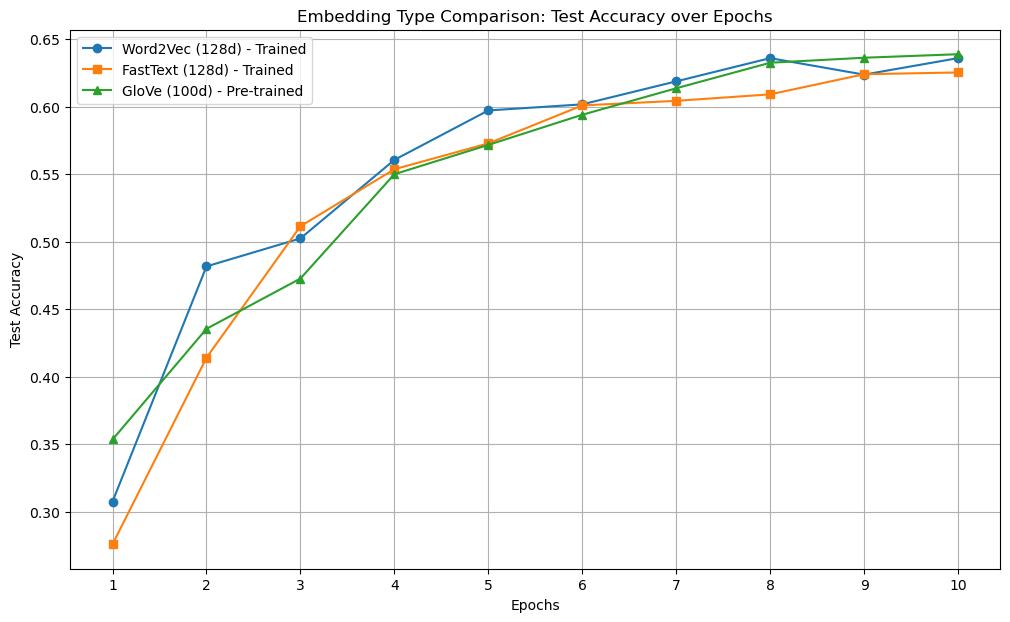


--- 3개 모델 최종 10 에포크 테스트 정확도 비교 ---
Word2Vec: 63.58%
FastText: 62.52%
GloVe:    63.87%


In [34]:
import matplotlib.pyplot as plt

# X축으로 사용할 에포크 리스트 (1부터 10까지)
# (N_EPOCHS는 10으로 이전에 정의됨)
epochs = range(1, N_EPOCHS + 1)

plt.figure(figsize=(12, 7))

# 1. Word2Vec (test_accuracies 리스트 사용)
# (리스트 이름이 정확한지 확인하세요. Step 6-2에서 정의함)
plt.plot(epochs, test_accuracies, 'o-', label='Word2Vec (128d) - Trained')

# 2. FastText (ft_test_accuracies 리스트 사용)
# (리스트 이름이 정확한지 확인하세요. Step 6-3에서 정의함)
plt.plot(epochs, ft_test_accuracies, 's-', label='FastText (128d) - Trained')

# 3. GloVe (glove_test_accuracies 리스트 사용)
# (리스트 이름이 정확한지 확인하세요. Step 6-4에서 정의함)
plt.plot(epochs, glove_test_accuracies, '^-', label='GloVe (100d) - Pre-trained')

plt.title('Embedding Type Comparison: Test Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Test Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(epochs) # X축 눈금을 1, 2, 3... 10으로 설정
plt.show()

# --- 최종 정확도 텍스트로 비교 (로그와 동일한지 재확인) ---
print("\n--- 3개 모델 최종 10 에포크 테스트 정확도 비교 ---")
print(f"Word2Vec: {test_accuracies[-1]*100:.2f}%")
print(f"FastText: {ft_test_accuracies[-1]*100:.2f}%")
print(f"GloVe:    {glove_test_accuracies[-1]*100:.2f}%")

## 4.News Group 텍스트 분류 모델 성능 비교 보고서

### 1. 프로젝트 개요

* **목표:** 20 News Group 데이터셋(18,846개 문서)을 20개 카테고리로 분류하는 RNN(LSTM) 모델을 구현합니다.
* **핵심 과제:** 세 가지 주요 단어 임베딩 방식(Word2Vec, FastText, GloVe)을 각각 적용하고, 10 에포크(Epoch) 학습 후 테스트 정확도(Accuracy)를 비교 분석합니다.

---

### 2. 실험 환경 및 전처리

* **모델 아키텍처:** `nn.LSTM`
    * **임베딩 층:** 각 방식에 따라 `freeze=False` (미세 조정 허용)로 설정
    * **LSTM 층:** 2-Layer Bidirectional (양방향), Hidden Dimension = 128
    * **분류기 층:** `Linear(256, 20)`
* **하이퍼파라미터:**
    * **Optimizer:** Adam (lr=0.001)
    * **Loss Function:** CrossEntropyLoss
    * **Batch Size:** 64
    * **Epochs:** 10
    * **Max Length:** 280 (훈련 데이터 95백분위수 기준)
* **텍스트 전처리:**
    * 소문자화, 영문자/공백 외 제거, NLTK 불용어 제거

---

### 3. 모델별 성능 비교

세 가지 임베딩 방식을 동일한 모델 구조와 하이퍼파라미터(Epoch 10회)로 학습시킨 결과입니다.

#### 📊 최종 성능 요약

| 임베딩 방식 | 임베딩 차원 | 학습 방식 | 최종 정확도 (10 Epoch) | 에포크당 평균 시간 | 사용 Device |
| :--- | :---: | :--- | :---: | :---: | :---: |
| **GloVe** | 100d | Pre-trained | **63.87%** | 약 125초 | CPU |
| **Word2Vec** | 128d | Trained on corpus | 63.58% | 약 130초 | CPU |
| **FastText** | 128d | Trained on corpus | 62.52% | **약 18초** | MPS |

#### 📈 에포크별 테스트 정확도 변화


*(`Step 7-1`에서 생성된 `plt.show()` 그래프가 여기에 해당됩니다.)*

---

### 4. 결과 분석 및 고찰

#### 1. 성능 (Accuracy)
* **세 모델의 성능은 대동소이함:** 10 에포크 학습 결과, 세 임베딩 방식 모두 **약 62~64%**의 최종 테스트 정확도를 기록했습니다. 이번 20 News Group 분류 태스크에서는 특정 임베딩이 압도적인 우위를 보이지는 않았습니다.
* **GloVe의 근소한 우위:** 스탠포드의 대용량 데이터로 사전 학습된(Pre-trained) **GloVe (63.87%)**가 우리 훈련 데이터로 직접 학습한(Trained on corpus) Word2Vec(63.58%)과 FastText(62.52%)보다 근소하게 높은 성능을 달성했습니다.
* **학습 안정성:** 그래프를 보면, GloVe가 다른 두 모델(특히 FastText)보다 초반(1~3 에포크)에 더 높은 정확도에서 시작하며 안정적으로 상승하는 경향을 보입니다. 이는 사전 학습된 벡터가 초기 학습 방향을 잡는 데 유리하게 작용했음을 시사합니다.

#### 2. 효율성 (Training Speed)
* **GPU(MPS) 가속의 압도적 효율:** 가장 주목할 점은 학습 속도입니다. **MPS**(`device`)를 사용한 FastText 모델은 에포크당 **약 18초**가 소요된 반면, **CPU**를 사용한 GloVe와 Word2Vec은 약 **125~130초**가 소요되었습니다.
* **결론:** 동일한 RNN 모델임에도 불구하고, 하드웨어 가속(GPU/MPS) 사용 여부가 학습 효율성에 **약 7배 이상**의 막대한 차이를 발생시켰습니다.

---

### 5. 최종 결론

본 미션에서 LSTM 모델과 세 가지 임베딩을 성공적으로 구현 및 평가했습니다.

* **성능 측면:** 사전 학습된 **GloVe**가 가장 근소하게 우수한 성능(63.87%)을 보임.
* **효율 측면:** MPS(GPU)를 활용한 학습이 CPU 대비 압도적으로 빨랐음.

## 5. 예측(Inference) 함수 정의

In [35]:
# (Step 1에서 로드한 label_names 변수가 필요합니다)
# label_names = news_data_all.target_names

def predict_category(text, model, word2idx, max_len, device, label_names):
    """
    하나의 텍스트 문장을 입력받아, 학습된 모델의 예측 카테고리를 반환합니다.
    """
    
    # 1. 모델을 평가 모드로 설정
    model.eval()
    
    # 2. 전처리
    tokens = clean_text(text) # Step 2-1에서 정의한 함수
    
    # 3. 인덱스 변환
    encoded = [word2idx.get(word, 1) for word in tokens] # 1 = [UNK]
    
    # 4. 패딩/트러케이션
    if len(encoded) < max_len:
        encoded += [0] * (max_len - len(encoded))
    else:
        encoded = encoded[:max_len]
        
    # 5. 텐서 변환 (device로 이동)
    input_tensor = torch.tensor(encoded, dtype=torch.long).to(device)
    
    # 6. 배치 차원 추가 [280] -> [1, 280]
    input_tensor = input_tensor.unsqueeze(0)
    
    # 기울기 계산 중지 (추론 시)
    with torch.no_grad():
        # 7. 모델 예측 (결과: [1, 20] 텐서)
        outputs = model(input_tensor)
        
        # 8. 가장 높은 점수의 인덱스 찾기
        # outputs.data -> [1, 20]
        # torch.max(..., 1) -> (값, 인덱스)
        _, predicted_idx_tensor = torch.max(outputs.data, 1)
        
        # 텐서에서 스칼라(숫자) 값 추출
        predicted_idx = predicted_idx_tensor.item() 
        
    # 9. 인덱스 -> 카테고리 이름 반환
    return label_names[predicted_idx], outputs

# --- 함수 정의 확인 ---
print("predict_category 함수가 정의되었습니다.")
print("다음 단계에서 이 함수를 사용해 실제 예측을 테스트해 보겠습니다.")


predict_category 함수가 정의되었습니다.
다음 단계에서 이 함수를 사용해 실제 예측을 테스트해 보겠습니다.


In [36]:
# --- 테스트할 모델과 재료 설정 ---
# (성능이 가장 좋았던 모델이나, 방금 학습한 GloVe 모델 사용)
test_model = model_glove
test_word2idx = word2idx_glove
# (max_len = 280, device, label_names는 이미 정의됨)
# ------------------------------------

# 1. 임의의 예시 문장 테스트
print("--- 임의의 예시 문장 테스트 ---")

# 예시 1: 컴퓨터/그래픽 관련
text1 = "I am looking for a new graphics card, maybe something from Nvidia or AMD to play games."
pred1, _ = predict_category(text1, test_model, test_word2idx, max_len, device, label_names)
print(f"입력: {text1}\n예측: {pred1}\n")

# 예시 2: 스포츠(야구) 관련
text2 = "The pitcher threw a fastball and the batter hit a home run. The crowd went wild."
pred2, _ = predict_category(text2, test_model, test_word2idx, max_len, device, label_names)
print(f"입력: {text2}\n예측: {pred2}\n")

# 예시 3: 종교/무신론 관련
text3 = "He argued that God does not exist, citing various philosophical and scientific reasons."
pred3, _ = predict_category(text3, test_model, test_word2idx, max_len, device, label_names)
print(f"입력: {text3}\n예측: {pred3}\n")


# 2. 실제 테스트 데이터셋 샘플 테스트
print("--- 실제 테스트 데이터셋 샘플 테스트 ---")
sample_index = 10 # 10번째 테스트 데이터 사용

original_text = test_texts[sample_index]
true_label = label_names[test_labels[sample_index]]
pred_label, raw_outputs = predict_category(original_text, test_model, test_word2idx, max_len, device, label_names)

print(f"입력 (일부): {original_text[:200]}...")
print(f"  [정답 카테고리]: {true_label}")
print(f"  [모델 예측 카테고리]: {pred_label}\n")

# (옵션) 모델이 반환한 20개 점수(raw_outputs) 중 상위 5개 확인
print(f"--- 모델의 '점수표(Logits)' 상세 보기 (샘플 {sample_index}) ---")
# raw_outputs를 CPU로 이동 (MPS/CUDA에 있을 수 있으므로)
scores = raw_outputs.cpu().squeeze() # [1, 20] -> [20]

# 점수를 소프트맥스를 이용해 확률(%)로 변환 (더 직관적)
import torch.nn.functional as F
probabilities = F.softmax(scores, dim=0)

# 상위 5개 확률과 카테고리 이름 출력
top5_probs, top5_indices = torch.topk(probabilities, 5)

for i in range(5):
    prob = top5_probs[i].item() * 100
    label = label_names[top5_indices[i].item()]
    print(f"{i+1}. {label}: {prob:.2f}%")

--- 임의의 예시 문장 테스트 ---
입력: I am looking for a new graphics card, maybe something from Nvidia or AMD to play games.
예측: comp.os.ms-windows.misc

입력: The pitcher threw a fastball and the batter hit a home run. The crowd went wild.
예측: rec.sport.baseball

입력: He argued that God does not exist, citing various philosophical and scientific reasons.
예측: talk.religion.misc

--- 실제 테스트 데이터셋 샘플 테스트 ---
입력 (일부): 

Maybe I should point out that we are not talking about c.s.amiga.*.
Only comp.graphics....
  [정답 카테고리]: comp.graphics
  [모델 예측 카테고리]: comp.graphics

--- 모델의 '점수표(Logits)' 상세 보기 (샘플 10) ---
1. comp.graphics: 72.37%
2. sci.electronics: 21.66%
3. sci.space: 1.32%
4. comp.sys.ibm.pc.hardware: 1.07%
5. comp.sys.mac.hardware: 0.81%
